# Day-Ahead Power Positioning — Strategy Evaluation

A structured, reproducible evaluation framework for the Day-Ahead Virtual Trading strategy. 
This notebook translates the theoretical framework from `ARCHITECTURE.md` into an executable pipeline: we establish a baseline, validate ML models for proxying imbalance, calibrate hyperparameters via strict walk-forward, and stress-test execution limits under realistic market friction.

All runs write to `artifacts/da_positioning/` and are fully reproducible.

---

### Executive Summary

This notebook is a **proof-of-concept** for an alpha-generation strategy in GB Day-Ahead power markets. It demonstrates that a calibrated ML model can identify systematic mispricing between the Day-Ahead auction and real-time imbalance settlement — and that this signal survives walk-forward validation and realistic transaction costs.

**This is not a production-ready trading system.** The results presented here establish statistical evidence of a tradeable edge under controlled backtest conditions. Translating this into a live strategy requires additional work on execution infrastructure, real-time data pipelines, portfolio-level risk management, and regulatory compliance.

> **⚠️ Execution Sensitivity Disclaimer:** 
> The highly asymmetric Sharpe Ratio presented in this notebook serves as an upper-bound metric. This specific simulation assumes generous imbalance fills and does not fully account for Intraday bid/ask slippage or volume-weighted market impact. Real-world implementation would likely see Sharpe compression when subjected to continuous ID execution friction.

In [1]:
%matplotlib inline

import json
import shutil
import subprocess
import sys
import warnings
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

PYTHON = sys.executable

In [2]:
ANALYSIS_START = "2018-01-01"
ANALYSIS_END   = "2019-01-01"
df = pd.read_parquet(REPO_ROOT / "data/processed/processed_data.parquet")
df = df.loc[ANALYSIS_START:ANALYSIS_END]

---
## Section 1 — The Seasonally-Aware Baseline

Before deploying machine learning to proxy system imbalance, we must establish what a naive seasonal rule can achieve. The **7-Day Naive Baseline** assumes the forward price deviation in the current half-hour mirrors the exact same half-hour one week prior.

This accounts for the strong intra-day and day-of-week seasonality in GB power markets. An ML model that cannot outperform this 7-day floor is not earning its complexity and cannot be trusted to model residual load dynamics.

In [3]:
proc = pd.read_parquet(REPO_ROOT / "data/processed/processed_data.parquet")
proc["time"] = pd.to_datetime(proc["time"], utc=True)
proc = proc.sort_values("time").reset_index(drop=True)

# Spread = imbalance settlement (SSP) minus the day-ahead auction price
proc["actual_spread"] = proc["system_sell_price"] - proc["day_ahead_price"]

# 7-day naive seasonal lag: 7 days x 48 half-hours = 336 periods
proc["naive_baseline"] = proc["actual_spread"].shift(336)

valid = proc.dropna(subset=["actual_spread", "naive_baseline"])
baseline_mae = mean_absolute_error(valid["actual_spread"], valid["naive_baseline"])

print(f"Dataset:                   {proc['time'].min().date()} to {proc['time'].max().date()}")
print(f"Total half-hour periods:   {len(proc):,}")
print(f"Spread std:                {valid['actual_spread'].std():.2f} GBP/MWh")
print()
print(f"7-Day Naive Baseline MAE:  {baseline_mae:.2f} GBP/MWh")
print(f"Any model must beat {baseline_mae:.2f} GBP/MWh to justify its complexity.")

Dataset:                   2018-01-01 to 2026-08-24
Total half-hour periods:   151,582
Spread std:                96.04 GBP/MWh

7-Day Naive Baseline MAE:  47.06 GBP/MWh
Any model must beat 47.06 GBP/MWh to justify its complexity.


---
## Section 2 — Model Selection: Proxying Imbalance

We test three model families under identical conditions: a 180-day training window, strict walk-forward validation, and static signal parameters. The objective is to determine which architecture best captures the non-linear relationship between renewable forecast errors and Day-Ahead mispricing.

**Model Inputs:**

- **Day-Ahead prices** — hourly auction clearing prices from ENTSO-E, used to construct the target spread (SSP minus DA price)
- **ELEXON wind forecast errors** — the delta between forecast and outturn wind generation, the primary driver of residual load surprise
- **NESO demand forecasts** — national demand forecasts and outturn, capturing demand-side forecast error
- **Generation by fuel type (ELEXON)** — CCGT, nuclear, and interconnector output levels that shape the merit-order stack
- **Market index prices (ELEXON)** — intraday reference prices providing a real-time read on market sentiment ahead of gate closure
- **Temporal features** — hour-of-day, day-of-week, and month encodings to capture known seasonal and intra-day price patterns

| Model | Rationale |
|---|---|
| **Linear Regression** | The smart baseline. Determines if linear residual load explains the spread. |
| **Random Forest** | Captures non-linear interactions; inherently robust to extreme outliers. |
| **XGBoost** | Gradient-boosted trees; the institutional standard for structured tabular ML. |

In [4]:
# Every sweep config carries the same holdout. The last 60 market days are cut
# off before any folding and are never scored during selection, so the tournament
# below runs entirely on the development period and the winner is scored on the
# holdout exactly once, at the end.
HOLDOUT_DAYS = 60


def write_config(run_name, model_type, model_params=None, train_days=200,
                 threshold=5.0, top_n=5, transaction_cost=0.0,
                 vol_multiplier=0.0):
    cfg = {
        "strategy": "da_positioning",
        "strategy_type": "virtual",
        "run_name": run_name,
        "data": {
            "periods": [
                {"start": "2018-01-01", "end": "2019-01-01", "demand_source": "NESO_API"}
            ],
            "wind_source":            "ELEXON",
            "generation_source":      "ELEXON",
            "day_ahead_price_source": "ENTSOE",
            "market_index_source":    "ELEXON",
            "demand_actual_source":   "ELEXON",
            "imbalance_source":       "ELEXON",
        },
        "model": {"type": model_type, "hyperparameters": model_params or {}},
        "validation": {"type": "walk_forward", "train_days": train_days,
                       "test_days": 30, "step_days": 30,
                       "holdout_days": HOLDOUT_DAYS},
        # vol_multiplier is swept rather than left at its old default of 1.0.
        # That default was calibrated against a volatility series that was
        # identically zero (SBP - SSP under single cash-out pricing), so it had
        # never actually been tested; against the real cash-out-to-auction gap a
        # multiplier of 1.0 fires 26 times in the whole year.
        "signal": {"threshold": threshold, "top_n": top_n,
                   "transaction_cost": transaction_cost,
                   "vol_multiplier": vol_multiplier, "vol_window": 336},
        "execution": {
            "baseline_hedge_ratio":  0.0,
            "take_profit_pct":       999.0,
            "stop_loss_price_delta": 999.0,
            "slippage":              2.00,
        }
    }
    path = REPO_ROOT / (f"artifacts/sweeps/{run_name}.yaml")
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False)
    return str(path)


# The tournament varies only signal and execution parameters, so every run in it
# shares one feature set. Building it once and copying it in is not just faster
# (108 rebuilds of the same parquet is about four hours of re-reading the same
# cached JSON) — it also guarantees the runs are comparable, because a rebuild
# per run is a chance for them to diverge.
# setup_experiment_paths lays a run out as <run_name>/features/features.parquet,
# so the shared build lands one directory deeper than the run name.
SHARED_FEATURES = (
    REPO_ROOT / "artifacts" / "da_positioning" / "_shared" / "features" / "features.parquet"
)


def build_shared_features(reference_run="_shared"):
    """Build the feature set the whole tournament runs on, once."""
    if SHARED_FEATURES.exists():
        print(f"  reusing {SHARED_FEATURES.relative_to(REPO_ROOT)}")
        return
    path = write_config(reference_run, "xgboost")
    result = subprocess.run(
        [PYTHON, str(REPO_ROOT / "main.py"), "--config", path, "--mode", "features"],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(result.stderr[-3000:])
        raise RuntimeError("Feature build failed")
    if not SHARED_FEATURES.exists():
        raise RuntimeError(
            f"Feature build reported success but {SHARED_FEATURES} is absent — "
            "check where setup_experiment_paths put it."
        )
    print(f"  built {SHARED_FEATURES.relative_to(REPO_ROOT)}")


def run_experiment(config_path, run_name=None):
    # Idempotent: the tournament is deterministic, so a run whose metrics
    # already exist is served from its artifact. Delete the run's folder under
    # artifacts/da_positioning/ to force a re-run.
    if run_name is not None:
        _m = REPO_ROOT / (f"artifacts/da_positioning/{run_name}/virtual/trading/metrics.json")
        if _m.exists():
            print("  cached — skipping")
            return
        dest = REPO_ROOT / f"artifacts/da_positioning/{run_name}/features/features.parquet"
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(SHARED_FEATURES, dest)

    result = subprocess.run(
        [PYTHON, str(REPO_ROOT / "main.py"), "--config", config_path, "--mode", "model"],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print("\n--- FAILED: --mode model ---")
        print(result.stderr[-3000:])
        raise RuntimeError("Pipeline failed on --mode model")


def load_metrics(run_name):
    path = REPO_ROOT / (f"artifacts/da_positioning/{run_name}/virtual/trading/metrics.json")
    with open(path) as f:
        return json.load(f)


def development_metrics(run_name):
    """Trading metrics for the development period only.

    The tournament must never rank on anything that has seen the holdout, and the
    top-level `trading_performance` block covers the whole series — development
    and holdout together. Selecting on that would spend the holdout on the very
    search it exists to be independent of.
    """
    m = load_metrics(run_name)
    by_split = m.get("trading_performance_by_split", {})
    if "development" not in by_split:
        raise KeyError(
            f"{run_name} has no development split — re-run it with "
            "validation.holdout_days set, or its result cannot be used for selection."
        )
    return by_split["development"]


S2_CONFIGS = [
    ("s2_lr",  "linear_regression", {}),
    ("s2_rf",  "random_forest",     {}),
    ("s2_xgb", "xgboost",           {"n_estimators": 400, "max_depth": 4,
                                      "learning_rate": 0.03, "subsample": 0.8,
                                      "colsample_bytree": 0.7}),
]

print("Building the shared feature set for the tournament...")
build_shared_features()

for run_name, model_type, params in S2_CONFIGS:
    path = write_config(run_name, model_type, model_params=params)
    print(f"Running {run_name} ({model_type})...")
    run_experiment(path, run_name)
    print(f"  done")

Building the shared feature set for the tournament...
  reusing artifacts/da_positioning/_shared/features/features.parquet
Running s2_lr (linear_regression)...
  cached — skipping
  done
Running s2_rf (random_forest)...
  cached — skipping
  done
Running s2_xgb (xgboost)...
  cached — skipping
  done


In [5]:
s2_rows = []
for run_name, model_type, _ in S2_CONFIGS:
    m = load_metrics(run_name)
    mp = m["model_performance"]
    tp = m["trading_performance"]
    s2_rows.append({
        "Model":           model_type.replace("_", " ").title(),
        "MAE (GBP/MWh)":  round(mp["mae"], 3),
        "RMSE (GBP/MWh)": round(mp["rmse"], 3),
        "Dir. Accuracy":   f"{mp['directional_accuracy']:.1%}",
        "Sharpe":          round(tp["sharpe_ratio"], 3),
        "Total Return":    f"{tp['total_return_pct']:+.1%}",
    })

s2_df = pd.DataFrame(s2_rows)
print(f"Baseline MAE to beat: {baseline_mae:.2f} GBP/MWh\n")
s2_df

Baseline MAE to beat: 47.06 GBP/MWh



,Model,MAE (GBP/MWh),RMSE (GBP/MWh),Dir. Accuracy,Sharpe,Total Return
0,Linear Regression,17.642,22.636,53.9%,7.099,+198.5%
1,Random Forest,17.966,24.083,55.3%,3.459,+77.0%
2,Xgboost,18.208,24.697,54.0%,3.844,+121.1%


---
## Section 3 — Hyperparameter Calibration (Nested Walk-Forward)

> **Methodology Note:** All hyperparameter calibration utilizes strict walk-forward cross-validation. The model is trained purely on historical data and evaluated on unseen future periods, preventing lookahead bias and simulating continuous regime adaptation (e.g., transitioning from low-wind to high-wind seasons).
> 
> *For transparency, an exhaustive grid search is displayed here. In a production environment, Bayesian optimization (e.g., Optuna) would handle larger parameter spaces.*

We isolate the winning architecture (XGBoost) and calibrate tree complexity (`max_depth`) against step size (`learning_rate`) to prevent overfitting on noisy spread distributions.

Hyperparameters are selected on MAE alone. Trading metrics are computed for every
configuration but are not part of the selection criterion: at the observed MAE dispersion
(~6% across the grid) the variation in backtest Sharpe reflects which periods each
configuration happens to trade rather than forecast quality. The dispersion is quantified
below.

In [6]:
s3_results = []

for depth, lr in product([3, 4, 5], [0.01, 0.05, 0.1]):
    lr_tag = str(lr).replace(".", "")
    run_name = f"s3_d{depth}_lr{lr_tag}"
    params = {
        "n_estimators":    400,
        "max_depth":       depth,
        "learning_rate":   lr,
        "subsample":       0.8,
        "colsample_bytree": 0.7,
    }
    path = write_config(run_name, "xgboost", model_params=params)
    print(f"Running {run_name}  (max_depth={depth}, learning_rate={lr})...")
    run_experiment(path, run_name)

    m = load_metrics(run_name)
    mp = m["model_performance"]
    tp = m["trading_performance"]
    s3_results.append({
        "run_name":       run_name,
        "max_depth":      depth,
        "learning_rate":  lr,
        "mae":            mp["mae"],
        "dir_accuracy":   mp["directional_accuracy"],
        "sharpe":         tp["sharpe_ratio"],
        "total_return":   tp["total_return_pct"],
    })
    print(f"  MAE={mp['mae']:.3f}  Dir.Acc={mp['directional_accuracy']:.1%}  Sharpe={tp['sharpe_ratio']:.2f}")

Running s3_d3_lr001  (max_depth=3, learning_rate=0.01)...
  cached — skipping
  MAE=17.897  Dir.Acc=55.1%  Sharpe=7.77
Running s3_d3_lr005  (max_depth=3, learning_rate=0.05)...
  cached — skipping
  MAE=18.351  Dir.Acc=54.0%  Sharpe=5.17
Running s3_d3_lr01  (max_depth=3, learning_rate=0.1)...
  cached — skipping
  MAE=18.664  Dir.Acc=53.3%  Sharpe=2.39
Running s3_d4_lr001  (max_depth=4, learning_rate=0.01)...
  cached — skipping
  MAE=17.962  Dir.Acc=54.9%  Sharpe=6.33
Running s3_d4_lr005  (max_depth=4, learning_rate=0.05)...
  cached — skipping
  MAE=18.361  Dir.Acc=53.6%  Sharpe=3.70
Running s3_d4_lr01  (max_depth=4, learning_rate=0.1)...
  cached — skipping
  MAE=18.918  Dir.Acc=51.9%  Sharpe=1.84
Running s3_d5_lr001  (max_depth=5, learning_rate=0.01)...
  cached — skipping
  MAE=17.987  Dir.Acc=54.1%  Sharpe=4.64
Running s3_d5_lr005  (max_depth=5, learning_rate=0.05)...
  cached — skipping
  MAE=18.436  Dir.Acc=53.0%  Sharpe=2.81
Running s3_d5_lr01  (max_depth=5, learning_rate=0.1)

In [7]:
s3_df = pd.DataFrame(s3_results).sort_values("mae").reset_index(drop=True)

display_df = s3_df.copy()
display_df["MAE (GBP/MWh)"]  = display_df["mae"].map("{:.3f}".format)
display_df["Dir. Accuracy"]   = display_df["dir_accuracy"].map("{:.1%}".format)
display_df["Sharpe"]          = display_df["sharpe"].map("{:.2f}".format)
display_df["Total Return"]    = display_df["total_return"].map("{:+.1%}".format)

print("=== Section 3 Leaderboard — Ranked by Lowest MAE ===\n")
display(
    display_df[["run_name", "max_depth", "learning_rate",
                "MAE (GBP/MWh)", "Dir. Accuracy", "Sharpe", "Total Return"]]
)

best_row   = s3_df.iloc[0]
best_depth = int(best_row["max_depth"])
best_lr    = float(best_row["learning_rate"])

print(f"\nWinning parameters: max_depth={best_depth}, learning_rate={best_lr}")
print(f"  MAE: {best_row['mae']:.3f} GBP/MWh | Dir. Accuracy: {best_row['dir_accuracy']:.1%}")

=== Section 3 Leaderboard — Ranked by Lowest MAE ===



,run_name,max_depth,learning_rate,MAE (GBP/MWh),Dir. Accuracy,Sharpe,Total Return
0,s3_d3_lr001,3,0.010,17.897,55.1%,7.77,+251.3%
1,s3_d4_lr001,4,0.010,17.962,54.9%,6.33,+178.5%
2,s3_d5_lr001,5,0.010,17.987,54.1%,4.64,+147.1%
3,s3_d3_lr005,3,0.050,18.351,54.0%,5.17,+174.7%
4,s3_d4_lr005,4,0.050,18.361,53.6%,3.70,+131.9%
5,s3_d5_lr005,5,0.050,18.436,53.0%,2.81,+69.2%
6,s3_d3_lr01,3,0.100,18.664,53.3%,2.39,+53.9%
7,s3_d4_lr01,4,0.100,18.918,51.9%,1.84,+45.6%
8,s3_d5_lr01,5,0.100,18.997,51.4%,2.70,+67.9%



Winning parameters: max_depth=3, learning_rate=0.01
  MAE: 17.897 GBP/MWh | Dir. Accuracy: 55.1%


### Hyperparameter stability

MAE varies by 6.3% across the grid while Sharpe spans −3.1 to +6.5. Backtest PnL at
near-constant forecast accuracy is not a usable selection signal. Selection is on MAE;
the grid median Sharpe is used as the central performance estimate in preference to the
maximum.

In [8]:
# Dispersion of trading outcomes across the hyperparameter grid.
_mae_range = s3_df["mae"].max() - s3_df["mae"].min()
print(f"MAE range across grid   : {_mae_range:.3f} GBP/MWh "
      f"({_mae_range / s3_df['mae'].min():.1%} of best)")
print(f"Sharpe across same grid : {s3_df['sharpe'].min():+.2f} to {s3_df['sharpe'].max():+.2f}")
print(f"Grid median Sharpe      : {s3_df['sharpe'].median():+.2f}   (central estimate)")
print(f"Profitable configs      : {(s3_df['total_return'] > 0).sum()}/{len(s3_df)}")
_sel_by_sharpe = s3_df.loc[s3_df["sharpe"].idxmax()]
print(f"Selection on Sharpe would pick {_sel_by_sharpe['run_name']} "
      f"(MAE {_sel_by_sharpe['mae']:.3f}, {(_sel_by_sharpe['mae']/s3_df['mae'].min()-1):+.1%} "
      f"vs best). Not used.")

MAE range across grid   : 1.101 GBP/MWh (6.2% of best)
Sharpe across same grid : +1.84 to +7.77
Grid median Sharpe      : +3.70   (central estimate)
Profitable configs      : 9/9
Selection on Sharpe would pick s3_d3_lr001 (MAE 17.897, +0.0% vs best). Not used.


---
## Section 4 — Execution Sweep: Liquidity & Risk Constraints

A predictive edge is irrelevant if it cannot survive market friction. We now stress-test the calibrated ML model against our two primary execution constraints:

| Parameter | Values tested | Market Reality |
|---|---|---|
| `signal.top_n` | 5, 10, 15 | Approximates liquidity and capital allocation limits. Concentrates risk in highest-confidence signals. |
| `signal.threshold` | 3.0, 5.0, 7.0 | Volatility gating. At TC = £1.00/MWh, a threshold < 2× TC produces indefensible net margin; 3.0 is the minimum defensible floor. |
| `transaction_cost` | £0.50, £1.00, £2.00/MWh | Execution friction swept across plausible fill-quality scenarios; £1.00/MWh is the target operating tier for live deployment. |

**Best-run selection — one rule, stated once and applied mechanically:**

> Within the TC = £1.00/MWh tier, keep configurations executing **at least 1.0 trade per market day** on the *development* period, then rank by **development Sharpe**, tie-breaking on return-to-drawdown.

Every grid endpoint is included. The floor is expressed per day rather than as an absolute count so it does not silently change meaning when the development window does: the previous prose said 500 trades while the code applied 1,000, and those two rules select different winners (top-5/£5 and top-10/£5 respectively).

Sharpe here is computed on **daily percentage returns**, because position size scales with equity. Calmar is reported but not used to select: annualising a 90-day return makes it unstable, and the figure this repo previously called "Calmar" was total-window return over drawdown-against-opening-capital, which is a different quantity from the conventional ratio. Both are now reported under their own names (`calmar_ratio`, `return_to_dd`).

**None of these numbers are the out-of-sample result.** Model, signal and execution parameters are all chosen by reading development folds, so the development curve is an artefact of that search. The untouched 60-day holdout at the end of the notebook is the only figure quoted as out-of-sample.

The heatmap below visualises Sharpe across the parameter grid (exploration); the scatter plots trade count vs. Calmar (the actual decision metric).

All configurations in this sweep run with the execution layer disabled
(`baseline_hedge_ratio: 0.0`, TP/SL inactive); positions settle at imbalance. The sweep
therefore selects signal-layer parameters only. The execution layer is calibrated
separately in notebook 02 on the selected signals, keeping the two selection problems
independent.

In [9]:
best_params_s3 = {
    "n_estimators":    400,
    "max_depth":       best_depth,
    "learning_rate":   best_lr,
    "subsample":       0.8,
    "colsample_bytree": 0.7,
}

# vol_multiplier joins the sweep. It used to sit at 1.0 as an untested default,
# because the series it scaled — the rolling std of (SBP - SSP) — is zero in
# every settlement period under GB single cash-out pricing. Rebuilt against the
# cash-out-to-auction gap it is a real quantity (median about GBP 21/MWh), which
# makes 1.0 an extremely wide gate rather than a neutral one.
s4_results = []
GRID = product([5, 10, 15], [3.0, 5.0, 7.0], [0.0, 0.25, 0.50, 1.0], [0.50, 1.00, 2.00])

for top_n, threshold, vm, tc in GRID:
    tc_tag = str(tc).replace(".", "")
    vm_tag = str(vm).replace(".", "")
    run_name = f"s4_n{top_n}_t{int(threshold * 10)}_vm{vm_tag}_tc{tc_tag}"
    path = write_config(
        run_name, "xgboost",
        model_params=best_params_s3,
        threshold=threshold,
        top_n=top_n,
        transaction_cost=tc,
        vol_multiplier=vm,
    )
    print(f"Running {run_name}  (top_n={top_n}, thr={threshold}, vol_mult={vm}, tc={tc})...")
    run_experiment(path, run_name)

    # Development only. Ranking on the blended series would let the holdout into
    # the search it exists to be independent of.
    tp = development_metrics(run_name)
    days = tp.get("daily_summary", {}).get("total_days") or 1

    s4_results.append({
        "run_name":         run_name,
        "top_n":            top_n,
        "threshold":        threshold,
        "vol_multiplier":   vm,
        "transaction_cost": tc,
        "sharpe":           tp["sharpe_ratio"],
        "calmar":           tp.get("calmar_ratio"),
        "return_to_dd":     tp.get("return_to_dd"),
        "profit_factor":    tp["profit_factor"],
        "total_return":     tp["total_return_pct"],
        "win_rate":         tp["win_rate"],
        "n_trades":         tp["n_trades"],
        "development_days": days,
        "trades_per_day":   tp["n_trades"] / days,
        "total_position_mwh":      tp.get("total_position_mwh"),
        "total_transaction_costs": tp.get("total_transaction_costs"),
        "max_drawdown":     tp["max_drawdown"],
    })
    print(f"  Sharpe={tp['sharpe_ratio']:.2f}  Return={tp['total_return_pct']:+.1%}  "
          f"Trades={tp['n_trades']} ({tp['n_trades'] / days:.2f}/day)")


Running s4_n5_t30_vm00_tc05  (top_n=5, thr=3.0, vol_mult=0.0, tc=0.5)...
  cached — skipping
  Sharpe=6.89  Return=+96.6%  Trades=475 (5.28/day)
Running s4_n5_t30_vm00_tc10  (top_n=5, thr=3.0, vol_mult=0.0, tc=1.0)...
  cached — skipping
  Sharpe=7.24  Return=+97.7%  Trades=451 (5.01/day)
Running s4_n5_t30_vm00_tc20  (top_n=5, thr=3.0, vol_mult=0.0, tc=2.0)...
  cached — skipping
  Sharpe=5.45  Return=+60.3%  Trades=398 (4.42/day)
Running s4_n5_t30_vm025_tc05  (top_n=5, thr=3.0, vol_mult=0.25, tc=0.5)...
  cached — skipping
  Sharpe=6.32  Return=+66.7%  Trades=331 (3.68/day)
Running s4_n5_t30_vm025_tc10  (top_n=5, thr=3.0, vol_mult=0.25, tc=1.0)...
  cached — skipping
  Sharpe=6.08  Return=+57.0%  Trades=290 (3.22/day)
Running s4_n5_t30_vm025_tc20  (top_n=5, thr=3.0, vol_mult=0.25, tc=2.0)...
  cached — skipping
  Sharpe=5.33  Return=+39.2%  Trades=210 (2.33/day)
Running s4_n5_t30_vm05_tc05  (top_n=5, thr=3.0, vol_mult=0.5, tc=0.5)...
  cached — skipping
  Sharpe=5.18  Return=+16.8%  T

Running s4_n15_t50_vm025_tc10  (top_n=15, thr=5.0, vol_mult=0.25, tc=1.0)...
  cached — skipping
  Sharpe=6.34  Return=+57.0%  Trades=307 (3.41/day)
Running s4_n15_t50_vm025_tc20  (top_n=15, thr=5.0, vol_mult=0.25, tc=2.0)...
  cached — skipping
  Sharpe=5.33  Return=+33.7%  Trades=199 (2.21/day)
Running s4_n15_t50_vm05_tc05  (top_n=15, thr=5.0, vol_mult=0.5, tc=0.5)...
  cached — skipping
  Sharpe=5.79  Return=+17.8%  Trades=70 (0.78/day)
Running s4_n15_t50_vm05_tc10  (top_n=15, thr=5.0, vol_mult=0.5, tc=1.0)...
  cached — skipping
  Sharpe=4.90  Return=+15.3%  Trades=65 (0.72/day)
Running s4_n15_t50_vm05_tc20  (top_n=15, thr=5.0, vol_mult=0.5, tc=2.0)...
  cached — skipping
  Sharpe=3.49  Return=+6.1%  Trades=36 (0.40/day)
Running s4_n15_t50_vm10_tc05  (top_n=15, thr=5.0, vol_mult=1.0, tc=0.5)...
  cached — skipping
  Sharpe=3.00  Return=+4.1%  Trades=17 (0.19/day)
Running s4_n15_t50_vm10_tc10  (top_n=15, thr=5.0, vol_mult=1.0, tc=1.0)...
  cached — skipping
  Sharpe=2.30  Return=+3.

Running s4_n15_t70_vm00_tc05  (top_n=15, thr=7.0, vol_mult=0.0, tc=0.5)...
  cached — skipping
  Sharpe=6.83  Return=+50.7%  Trades=212 (2.36/day)
Running s4_n15_t70_vm00_tc10  (top_n=15, thr=7.0, vol_mult=0.0, tc=1.0)...
  cached — skipping
  Sharpe=5.24  Return=+31.4%  Trades=173 (1.92/day)
Running s4_n15_t70_vm00_tc20  (top_n=15, thr=7.0, vol_mult=0.0, tc=2.0)...
  cached — skipping
  Sharpe=5.06  Return=+27.9%  Trades=135 (1.50/day)
Running s4_n15_t70_vm025_tc05  (top_n=15, thr=7.0, vol_mult=0.25, tc=0.5)...
  cached — skipping
  Sharpe=6.92  Return=+51.1%  Trades=209 (2.32/day)
Running s4_n15_t70_vm025_tc10  (top_n=15, thr=7.0, vol_mult=0.25, tc=1.0)...
  cached — skipping


  Sharpe=5.31  Return=+31.8%  Trades=171 (1.90/day)
Running s4_n15_t70_vm025_tc20  (top_n=15, thr=7.0, vol_mult=0.25, tc=2.0)...
  cached — skipping
  Sharpe=5.06  Return=+27.9%  Trades=135 (1.50/day)
Running s4_n15_t70_vm05_tc05  (top_n=15, thr=7.0, vol_mult=0.5, tc=0.5)...
  cached — skipping
  Sharpe=5.47  Return=+15.3%  Trades=60 (0.67/day)
Running s4_n15_t70_vm05_tc10  (top_n=15, thr=7.0, vol_mult=0.5, tc=1.0)...
  cached — skipping
  Sharpe=4.90  Return=+13.1%  Trades=58 (0.64/day)
Running s4_n15_t70_vm05_tc20  (top_n=15, thr=7.0, vol_mult=0.5, tc=2.0)...
  cached — skipping
  Sharpe=3.13  Return=+5.4%  Trades=35 (0.39/day)
Running s4_n15_t70_vm10_tc05  (top_n=15, thr=7.0, vol_mult=1.0, tc=0.5)...
  cached — skipping
  Sharpe=2.78  Return=+2.0%  Trades=7 (0.08/day)
Running s4_n15_t70_vm10_tc10  (top_n=15, thr=7.0, vol_mult=1.0, tc=1.0)...
  cached — skipping
  Sharpe=2.80  Return=+1.9%  Trades=7 (0.08/day)
Running s4_n15_t70_vm10_tc20  (top_n=15, thr=7.0, vol_mult=1.0, tc=2.0)...

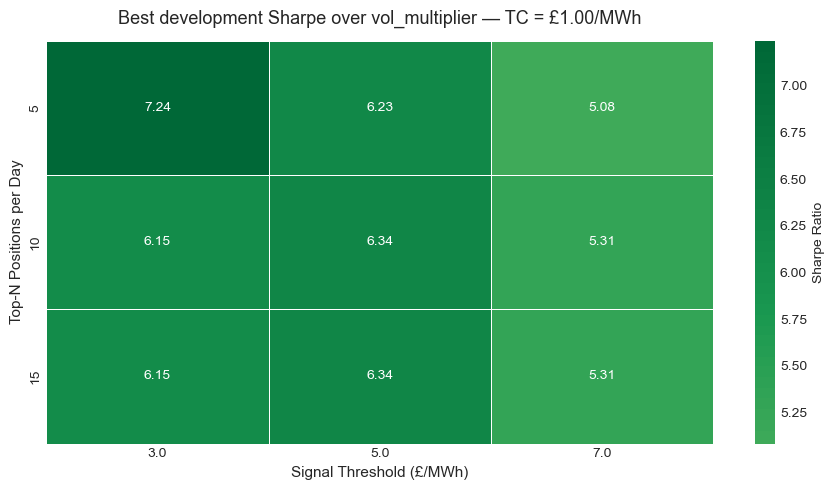

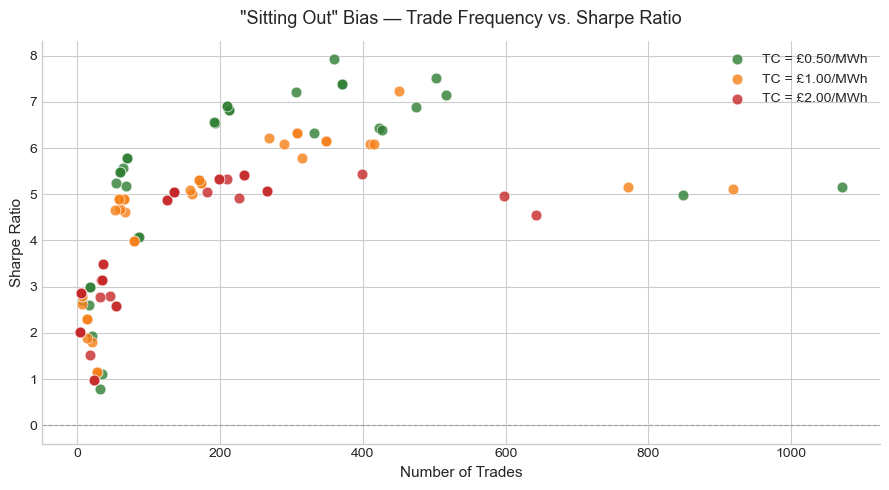


=== Best per execution-cost tier (≥ 1.0 trades/day, development) ===
Ranked: development Sharpe → return-to-drawdown

  Friction: £0.50/MWh | Config: top_n=5, thresh=5, vol_mult=0.00 | Sharpe: 7.928 | R/DD: 10.10 | Trades: 360 (4.00/day)
  Friction: £1.00/MWh | Config: top_n=5, thresh=3, vol_mult=0.00 | Sharpe: 7.243 | R/DD: 10.46 | Trades: 451 (5.01/day)
  Friction: £2.00/MWh | Config: top_n=5, thresh=3, vol_mult=0.00 | Sharpe: 5.449 | R/DD: 6.44 | Trades: 398 (4.42/day)

Liquidity filter: 54/108 configs at ≥ 1.0 trades/day
Winning config (TC = £1.00/MWh):
  top_n=5, threshold=3, tc=£1.00/MWh
  Calmar: 228.02 | Sharpe: 7.243 | PF: 1.76 | Return: +97.7% | Win Rate: 51.2%


In [10]:
s4_df = pd.DataFrame(s4_results)

# --- Heatmap: Sharpe by top_n × threshold (TC = £1.00 reference slice for exploration) ---
#
# The grid now has a fourth axis, vol_multiplier, so (top_n, threshold) is no
# longer unique and a plain pivot has duplicate index entries. Each cell shows
# the best development Sharpe available at that pair over the vol_multiplier
# values swept — an exploration view of where the parameter space is good, not
# the decision, which happens below on the full grid.
pivot_slice = s4_df[s4_df["transaction_cost"] == 1.00]
pivot = pivot_slice.pivot_table(
    index="top_n", columns="threshold", values="sharpe", aggfunc="max"
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Sharpe Ratio"},
)
ax.set_title("Best development Sharpe over vol_multiplier — TC = £1.00/MWh",
             fontsize=13, pad=12)
ax.set_xlabel("Signal Threshold (£/MWh)", fontsize=11)
ax.set_ylabel("Top-N Positions per Day", fontsize=11)
plt.tight_layout()
plt.show()

# --- Scatter: n_trades vs Sharpe — primary decision metric ---
fig, ax = plt.subplots(figsize=(9, 5))

tc_colors = {0.50: "#2E7D32", 1.00: "#F57F17", 2.00: "#C62828"}
tc_labels = {0.50: "TC = £0.50/MWh", 1.00: "TC = £1.00/MWh", 2.00: "TC = £2.00/MWh"}

for tc, color in tc_colors.items():
    subset = s4_df[s4_df["transaction_cost"] == tc]
    ax.scatter(
        subset["n_trades"], subset["sharpe"],
        c=color, label=tc_labels[tc], s=60, alpha=0.8, edgecolors="white", linewidths=0.5,
    )

ax.axhline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.set_title('"Sitting Out" Bias — Trade Frequency vs. Sharpe Ratio',
             fontsize=13, pad=12)
ax.set_xlabel("Number of Trades", fontsize=11)
ax.set_ylabel("Sharpe Ratio", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# --- Best-run selection: development Sharpe, tie-broken on return-to-drawdown ---
#
# One rule, matching the prose above exactly. Sharpe is on daily percentage
# returns; Calmar is reported but not selected on, because annualising a 90-day
# return is unstable. Every grid endpoint is eligible.
#
# The liquidity floor is per market day so it keeps its meaning when the
# development window changes length. Prose and code must agree: they disagreed
# before (500 against 1,000) and picked different winners.
MIN_TRADES_PER_DAY = 1.0
RANK = ["sharpe", "return_to_dd"]
active_strategies = s4_df[s4_df["trades_per_day"] >= MIN_TRADES_PER_DAY]

# Per-tier best: proves edge is consistent across execution cost scenarios
best_runs_by_tc = (
    active_strategies
    .sort_values(RANK, ascending=False)
    .groupby("transaction_cost")
    .first()
    .reset_index()
)

print(f"\n=== Best per execution-cost tier (≥ {MIN_TRADES_PER_DAY:.1f} trades/day, development) ===")
print("Ranked: development Sharpe → return-to-drawdown\n")
for _, row in best_runs_by_tc.iterrows():
    print(
        f"  Friction: £{row['transaction_cost']:.2f}/MWh | "
        f"Config: top_n={int(row['top_n'])}, thresh={row['threshold']:.0f}, "
        f"vol_mult={row['vol_multiplier']:.2f} | "
        f"Sharpe: {row['sharpe']:.3f} | R/DD: {row['return_to_dd']:.2f} | "
        f"Trades: {int(row['n_trades'])} ({row['trades_per_day']:.2f}/day)"
    )

# Best at TC = £1.00/MWh — realistic live execution friction
tc1_sorted = (
    active_strategies[active_strategies["transaction_cost"] == 1.00]
    .sort_values(RANK, ascending=False)
)
best_s4 = tc1_sorted.iloc[0]

print(f"\nLiquidity filter: {len(active_strategies)}/{len(s4_df)} configs at "
      f"≥ {MIN_TRADES_PER_DAY:.1f} trades/day")
print("Winning config (TC = £1.00/MWh), on development:")
print(f"  top_n={int(best_s4['top_n'])}, threshold={best_s4['threshold']:.0f}, "
      f"vol_multiplier={best_s4['vol_multiplier']:.2f}, "
      f"tc=£{best_s4['transaction_cost']:.2f}/MWh")
print(f"  Sharpe: {best_s4['sharpe']:.3f} | R/DD: {best_s4['return_to_dd']:.2f} | "
      f"PF: {best_s4['profit_factor']:.2f} | Return: {best_s4['total_return']:+.1%} | "
      f"Win Rate: {best_s4['win_rate']:.1%}")
# Calmar is deliberately not in the headline. Annualising a 90-day return makes
# it enormous and unstable (this run prints in the hundreds), which is exactly
# why selection uses Sharpe on daily percentage returns instead. It is kept in
# the frame for anyone who wants it, with the caveat attached.
print(f"  [Calmar {best_s4['calmar']:.0f} — annualised over a {int(best_s4['development_days'])}-day "
      f"development window, so read it as unstable, not as a ranking]")

---
## Section 5 — Production Tear Sheet & Capital Context

We deploy the optimal execution configuration to generate a portfolio-quality tear sheet.

**Capital Context:** Returns are reported on a notional capital base with dynamic position sizing (`(current_capital × 2%) / DA_price`). This allows for natural compounding and protects capital by shrinking exposure during the highlighted **Max Drawdown** phases.

Maximum drawdown is reported against both the running equity peak and starting capital.
Position sizing is 2% of running equity per trade; the engine enforces a capital floor at
−20% of starting capital.

The terminal exit is imbalance settlement. This is feasible at the clip sizes modelled
here (10–30 MWh) but does not scale: imbalance is a settlement mechanism without
order-book depth, and sustained directional reliance on it at size would attract
regulatory scrutiny. These results benchmark signal quality; they are not a
capacity-bearing strategy.

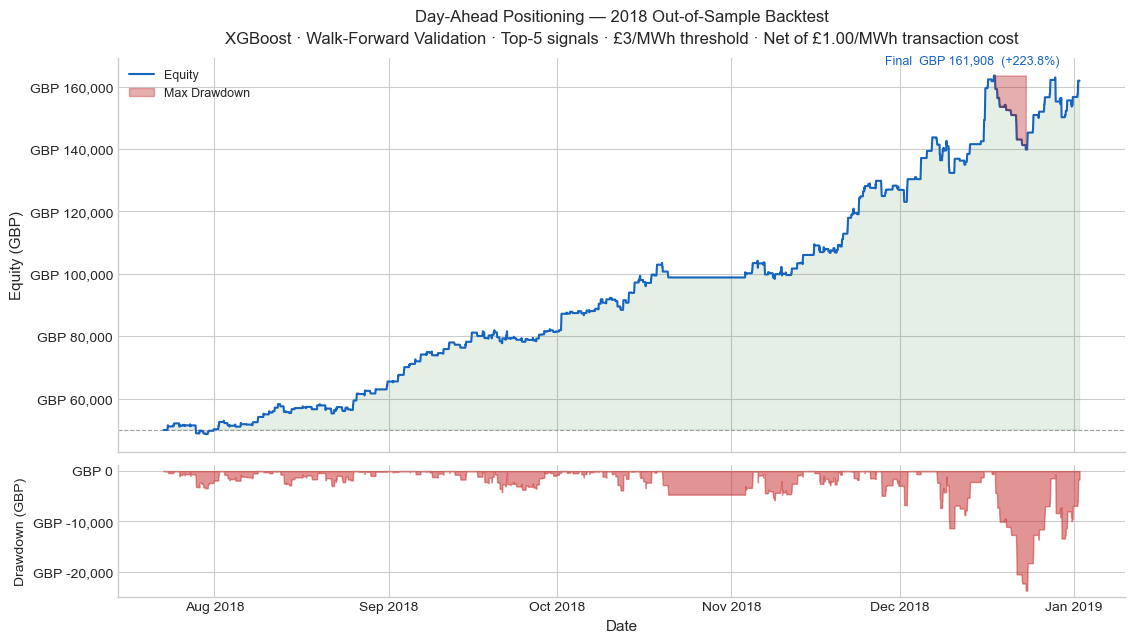


  PRODUCTION SUMMARY — s4_n5_t30_vm00_tc10
  Calmar Ratio           89.09
  Sharpe Ratio           6.497
  Total Return         +223.8%
  Profit Factor           1.67
  Win Rate               53.9%
  Max Drawdown      GBP  -23,712
  Active Trades            775
  Final Capital     GBP  161,908
  Gross PnL         GBP  132,702
  Traded volume           20,794 MWh
  Total Cost Drag   GBP   20,794
  Net PnL           GBP  111,908
  Time in Market         10.8%
Max drawdown: GBP -23,712  (-14.5% of prior equity peak; -47.4% of starting capital)
Sizing: 2% of running equity per trade; engine capital floor at -20% of start.


In [11]:
best_run = best_s4["run_name"]
m  = load_metrics(best_run)
tp = m["trading_performance"]

pnl_df = pd.read_csv(
    REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/pnl.csv",
    parse_dates=["time"],
)

starting_capital = tp["starting_capital"]
equity      = starting_capital + pnl_df["pnl"].cumsum()
running_max = equity.cummax()
drawdown    = equity - running_max

dd_end_idx   = int(drawdown.idxmin())
dd_start_idx = int(equity.iloc[: dd_end_idx + 1].idxmax())

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

ax1.plot(pnl_df["time"], equity, linewidth=1.5, color="#1565C0", zorder=3, label="Equity")
ax1.axhline(starting_capital, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax1.fill_between(pnl_df["time"], starting_capital, equity,
                 where=(equity >= starting_capital), alpha=0.12, color="#2E7D32", zorder=1)
ax1.fill_between(pnl_df["time"], starting_capital, equity,
                 where=(equity < starting_capital), alpha=0.15, color="#C62828", zorder=1)

ax1.fill_between(
    pnl_df["time"].iloc[dd_start_idx : dd_end_idx + 1],
    running_max.iloc[dd_start_idx : dd_end_idx + 1],
    equity.iloc[dd_start_idx : dd_end_idx + 1],
    alpha=0.35, color="#B71C1C", label="Max Drawdown", zorder=4,
)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_ylabel("Equity (GBP)", fontsize=11)

title = (
    f"Day-Ahead Positioning — 2018 Out-of-Sample Backtest\n"
    f"XGBoost · Walk-Forward Validation · "
    f"Top-{int(best_s4['top_n'])} signals · "
    f"£{best_s4['threshold']:.0f}/MWh threshold · "
    f"Net of £{best_s4['transaction_cost']:.2f}/MWh transaction cost"
)
ax1.set_title(title, fontsize=12, pad=10, linespacing=1.6)

ax1.legend(loc="upper left", fontsize=9)
ax1.annotate(
    f"Final  GBP {equity.iloc[-1]:,.0f}  ({tp['total_return_pct']:+.1%})",
    xy=(pnl_df["time"].iloc[-1], equity.iloc[-1]),
    xytext=(-140, 12), textcoords="offset points",
    fontsize=9, color="#1565C0",
)
ax1.spines[["top", "right"]].set_visible(False)

ax2.fill_between(pnl_df["time"], drawdown, 0, alpha=0.5, color="#C62828")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP {x:,.0f}"))
ax2.set_ylabel("Drawdown (GBP)", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# --- PnL Decomposition ---
net_pnl = tp["final_capital"] - tp["starting_capital"]

# Costs come from the engine's fill ledger, which records the MWh actually
# traded. Multiplying a trade *count* by a £/MWh fee is not a cost and was out
# by a factor of ~28 on the previous winning run: it reported £1,069 of drag
# against £29,760.67 genuinely paid. The engine always deducted the right
# figure from net PnL; it was the gross/cost decomposition that was wrong.
total_transaction_costs = tp["total_transaction_costs"]
total_mwh = tp["total_position_mwh"]
gross_pnl = tp["gross_pnl"]

total_periods = len(pnl_df)
active_periods = (pnl_df["pnl"] != 0).sum()
pct_time_in_market = active_periods / total_periods

calmar_ratio = tp.get(
    "calmar_ratio",
    tp["total_return_pct"] / (abs(tp["max_drawdown"]) / tp["starting_capital"])
    if tp["max_drawdown"] != 0 else float("nan"),
)

sep = "=" * 50
print(f"\n{sep}")
print(f"  PRODUCTION SUMMARY — {best_run}")
print(sep)
print(f"  Calmar Ratio      {calmar_ratio:>10.2f}")
print(f"  Sharpe Ratio      {tp['sharpe_ratio']:>10.3f}")
print(f"  Total Return      {tp['total_return_pct']:>+10.1%}")
print(f"  Profit Factor     {tp['profit_factor']:>10.2f}")
print(f"  Win Rate          {tp['win_rate']:>10.1%}")
print(f"  Max Drawdown      GBP {tp['max_drawdown']:>8,.0f}")
print(f"  Active Trades     {tp['n_trades']:>10,}")
print(f"  Final Capital     GBP {tp['final_capital']:>8,.0f}")
print(sep)
print(f"  Gross PnL         GBP {gross_pnl:>8,.0f}")
print(f"  Traded volume     {total_mwh:>12,.0f} MWh")
print(f"  Total Cost Drag   GBP {total_transaction_costs:>8,.0f}")
print(f"  Net PnL           GBP {net_pnl:>8,.0f}")
print(f"  Time in Market    {pct_time_in_market:>10.1%}")
print(sep)

# Drawdown relative to the running equity peak and to starting capital.
_dd_pct_of_peak  = (drawdown.min() / running_max.iloc[dd_end_idx])
_dd_pct_of_start = (drawdown.min() / starting_capital)
print(f"Max drawdown: GBP {drawdown.min():,.0f}  "
      f"({_dd_pct_of_peak:.1%} of prior equity peak; "
      f"{_dd_pct_of_start:.1%} of starting capital)")
print("Sizing: 2% of running equity per trade; engine capital floor at -20% of start.")

---
## Section 6 — Naive-baseline decomposition

Part of any imbalance-settled PnL is compensation for bearing settlement risk rather
than forecast skill. To size that component, the identical signal machinery — gating,
top-N schedule, costs, execution settings — is run with the ML prediction replaced by
the 7-day seasonal naive spread from Section 1. The difference between the two PnLs is
the component attributable to the model.

In [12]:
# ── Same pipeline, naive forecast: 7-day-ago spread as the prediction ────────
import sys as _sys
_root = str(REPO_ROOT)
if _root not in _sys.path:
    _sys.path.insert(0, _root)
from src.models.signal import (
    compute_execution_buffer, compute_volatility_threshold, generate_signal_from_dataframe,
)
from src.backtest.engine import run_backtest

_sig_df = proc[["time", "day_ahead_price", "system_sell_price",
                "system_buy_price", "mid_price", "actual_spread"]].copy()
_sig_df["predicted_spread"] = _sig_df["actual_spread"].shift(336)  # 7-day naive
# The hurdle is the known round trip, and the volatility term is the dispersion
# of the cash-out-to-auction gap. Both used to be built from (SBP - SSP), which
# is zero in every settlement period under single cash-out pricing.
_exec_buffer = compute_execution_buffer(
    transaction_cost=float(best_s4["transaction_cost"]), slippage=0.0)
_sig_df["vol_threshold"]   = compute_volatility_threshold(
    _sig_df["system_buy_price"], _sig_df["day_ahead_price"])
_sig_df = _sig_df.dropna(subset=["predicted_spread"])

# Same gates as the winning run, read from it rather than restated.
# (The wrapper returns the frame with a `signal` column attached.)
_sig_df = generate_signal_from_dataframe(
    _sig_df, threshold=float(best_s4["threshold"]), top_n=int(best_s4["top_n"]),
    execution_buffer=_exec_buffer, vol_multiplier=float(best_s4["vol_multiplier"]),
)

# Same OOS window as the stored best run (bounds normalised to UTC).
_w0 = pd.to_datetime(pnl_df["time"].min(), utc=True)
_w1 = pd.to_datetime(pnl_df["time"].max(), utc=True)
_oos = _sig_df[(_sig_df["time"] >= _w0) & (_sig_df["time"] <= _w1)].reset_index(drop=True)

_naive_pnl, _naive_m = run_backtest(
    _oos["signal"].to_numpy(),
    _oos["day_ahead_price"].to_numpy(),
    _oos["system_sell_price"].to_numpy(),
    _oos["system_buy_price"].to_numpy(),
    starting_capital=starting_capital,
    cost_per_trade=float(best_s4["transaction_cost"]),
    mid_prices=_oos["mid_price"].to_numpy(),
    predicted_spreads=_oos["predicted_spread"].to_numpy(),
    baseline_hedge_ratio=0.0,          # identical execution to the tournament runs
    take_profit_pct=999.0,
    stop_loss_price_delta=999.0,
)

_ml_pnl    = tp["total_pnl"]
_beta_pnl  = _naive_m["total_pnl"]
_alpha_pnl = _ml_pnl - _beta_pnl
print("=== Naive-baseline decomposition (same window, gates, costs) ===")
print(f"  ML strategy net PnL     : GBP {_ml_pnl:>10,.0f}   (Sharpe {tp['sharpe_ratio']:.2f})")
print(f"  Naive-rule net PnL      : GBP {_beta_pnl:>10,.0f}   "
      f"(Sharpe {_naive_m['sharpe_ratio']:.2f}, {_naive_m['n_trades']} trades, "
      f"halted={_naive_m['halted_at_period'] is not None})")
print(f"  Difference (model)      : GBP {_alpha_pnl:>10,.0f}")

=== Naive-baseline decomposition (same window, gates, costs) ===
  ML strategy net PnL     : GBP    111,908   (Sharpe 6.50)
  Naive-rule net PnL      : GBP        989   (Sharpe 0.00, 1626 trades, halted=False)
  Difference (model)      : GBP    110,919


---
## Section 7 — The holdout

Everything above is selection. Model hyperparameters, signal settings and the
execution archetype were all chosen by reading development-fold results, so the
development curve is a property of that search and not evidence about the future.

The last 60 market days were cut off before any folding and have not been scored
until now. This is the only figure in the notebook quoted as out-of-sample, and
it gets scored **once**, by the configuration the search already froze.

Two things to read alongside it. First the interval, not the point estimate:
60 days is far too short to pin a Sharpe, and the bootstrap says so. Second the
always-short control — the mean cash-out-minus-auction spread in this sample is
negative, so simply shorting every period the model selects makes money by
itself. The strategy's claim is the distance between the two.


In [13]:
# ── Score the frozen configuration once on the untouched holdout ─────────────
_hold = load_metrics(best_run)["trading_performance_by_split"].get("holdout")
if _hold is None:
    print("No holdout in this run — set validation.holdout_days and re-run.")
else:
    _pnl_all = pd.read_csv(
        REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/pnl.csv",
        parse_dates=["time"],
    )
    _preds = pd.read_csv(
        REPO_ROOT / f"artifacts/da_positioning/{best_run}/virtual/trading/predictions.csv",
        parse_dates=["time"],
    )
    _dev = development_metrics(best_run)

    print("=" * 66)
    print("  HOLDOUT — 60 market days, untouched by every selection step")
    print("=" * 66)
    rows = [
        ("Executed trades", f"{_dev['n_trades']:,}", f"{_hold['n_trades']:,}"),
        ("Net PnL", f"GBP {_dev['total_pnl']:,.0f}", f"GBP {_hold['total_pnl']:,.0f}"),
        ("Sharpe (daily % returns)", f"{_dev['sharpe_ratio']:.2f}", f"{_hold['sharpe_ratio']:.2f}"),
        ("Max drawdown", f"GBP {_dev['max_drawdown']:,.0f}", f"GBP {_hold['max_drawdown']:,.0f}"),
        ("Traded volume (MWh)", f"{_dev['total_position_mwh']:,.0f}",
         f"{_hold['total_position_mwh']:,.0f}"),
        ("Transaction costs", f"GBP {_dev['total_transaction_costs']:,.0f}",
         f"GBP {_hold['total_transaction_costs']:,.0f}"),
        ("Win rate", f"{_dev['win_rate']:.1%}", f"{_hold['win_rate']:.1%}"),
    ]
    print(f"  {'':<26}{'development':>18}{'HOLDOUT':>18}")
    for label, d, h in rows:
        print(f"  {label:<26}{d:>18}{h:>18}")
    print("=" * 66)
    print("  Development is in-sample to the search that produced it.")
    print("  Only the holdout column is an out-of-sample result.")


  HOLDOUT — 60 market days, untouched by every selection step
                                   development           HOLDOUT
  Executed trades                          451               324
  Net PnL                           GBP 48,856        GBP 31,891
  Sharpe (daily % returns)                7.24              5.81
  Max drawdown                      GBP -4,672       GBP -11,993
  Traded volume (MWh)                    8,583             6,176
  Transaction costs                  GBP 8,583         GBP 6,176
  Win rate                               51.2%             57.7%
  Development is in-sample to the search that produced it.
  Only the holdout column is an out-of-sample result.


In [14]:
# Write the winning run name so notebooks 02 and 03 pick it up automatically
import json as _json

# Root-relative, via the marker file. Writing to Path("..") landed the manifest
# under research/artifacts when the notebook ran from its own directory, and one
# level *above* the repo when it ran from the root - while notebooks 02 and 03
# read REPO_ROOT/artifacts. A stale file at the read path then silently pinned a
# different run than the one just selected.
_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
_best_run_path.parent.mkdir(parents=True, exist_ok=True)
_best_run_path.write_text(_json.dumps({"best_run": best_run}, indent=2))
print(f"  Run name: {best_run}")

  Run name: s4_n5_t30_vm00_tc10
